# Dataset Understanding

1. What are the rows and columns
2. which is column can be the target variable
3. what are the datatypes of the column
4. what means does the column infer

## Data Loading & Initial Inspection

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data = pd.read_csv("train.csv")

In [3]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
list(data.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [5]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [6]:
for values in list(data.columns):
    print(f"{values} count: {data[values].nunique()}")

PassengerId count: 891
Survived count: 2
Pclass count: 3
Name count: 891
Sex count: 2
Age count: 88
SibSp count: 7
Parch count: 7
Ticket count: 681
Fare count: 248
Cabin count: 147
Embarked count: 3


In [7]:
data.shape

(891, 12)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
data.describe(include= ["object", "string"])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


# Objective & Hypothesis

### What business/data questions can be asked?
(Every business question and data question should ultimately help explain, predict, or improve the target variable.)

### Initial hypotheses
(based on business questions)

# Data Cleaning

## 1. Handling MIssing Values

In [11]:
# check how many null values are there in the data 
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# to decide whether the feature should be dropped or not 
print((data.isnull().sum() / len(data)) * 100)


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


#### for features with missing values > 50% i.e cabin, let's investigate 

In [13]:
# 1. understand cabin data 
data["Cabin"].head(10)

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: str

In [14]:
data["Cabin"].mode()

0        B96 B98
1    C23 C25 C27
2             G6
Name: Cabin, dtype: str

In [15]:
# making a copy of the data to avoid changes in the original data 
df = data

In [16]:
# if we rethink why we need cabin, we realise that we only need deck (lower deck, upper deck) cabin doesn't matter so extract deck from cabin
df["Deck"] = df["Cabin"].str[0]

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN


In [18]:
# now fill the missing values of the deck with "unknown"
df["Deck"] = df["Deck"].fillna("Unknown")

In [19]:
df['Deck'].unique()

<StringArray>
['Unknown', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

In [20]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [21]:
df["Embarked"].isnull().sum()

np.int64(0)

In [22]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [23]:
df.drop("Cabin", axis= 1, inplace= True)

In [24]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64

## 2. Handling duplicates

In [25]:
df.duplicated().sum()

np.int64(0)

## 3. Handling improper datatypes

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  Deck         891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [27]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Handling outliers
(check for continuous values and also verify categorical values)

In [28]:
# checking that it is continuous data or not 
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [29]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [30]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [31]:
df["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

<Axes: xlabel='Age'>

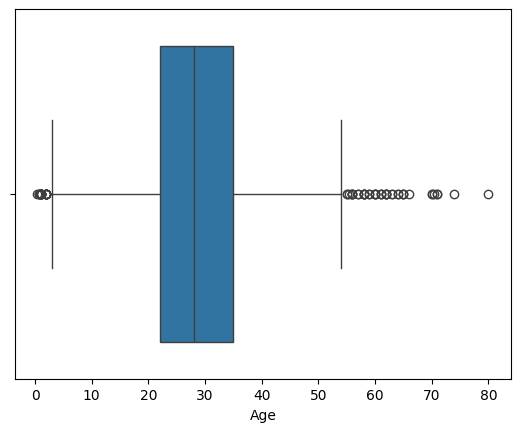

In [32]:
sns.boxplot(x = df["Age"])

<Axes: xlabel='Fare'>

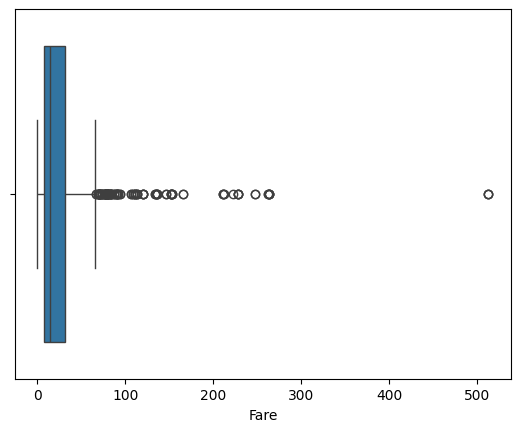

In [33]:
sns.boxplot(x=df["Fare"])

# EDA

## 1. Univariate Analysis

1. Age

<Axes: xlabel='Age', ylabel='Count'>

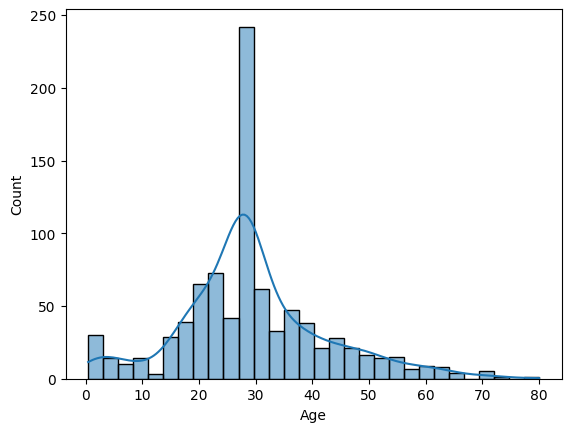

In [34]:
sns.histplot(df, x= "Age", kde= True)

In [35]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

2. Fare

<Axes: xlabel='Fare', ylabel='Count'>

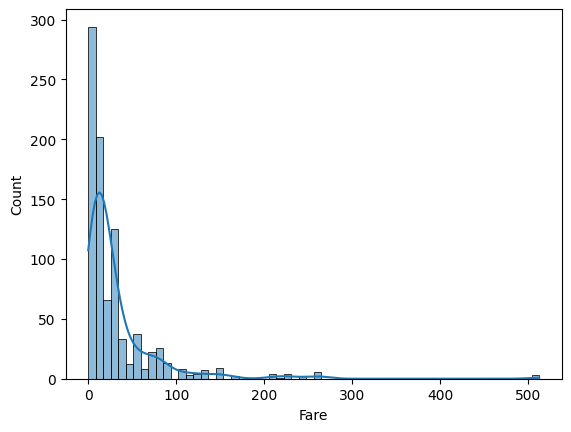

In [36]:
sns.histplot(df, x= "Fare", kde= True)

In [37]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

3. Survived

In [38]:
df["Survived"].value_counts(normalize= True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

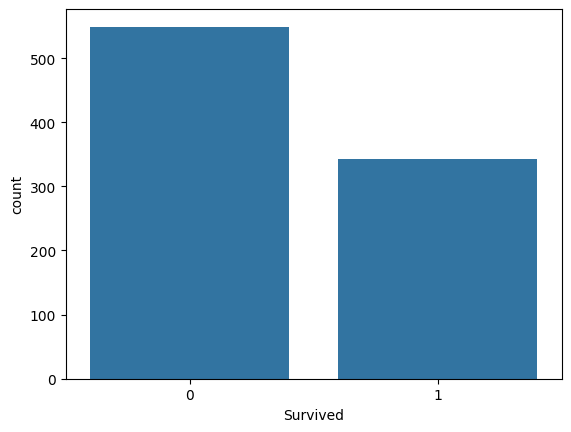

In [39]:
sns.countplot(data = df, x= "Survived")

4. Pclass

In [40]:
df["Pclass"].value_counts(normalize= True) * 100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

<Axes: xlabel='Pclass', ylabel='count'>

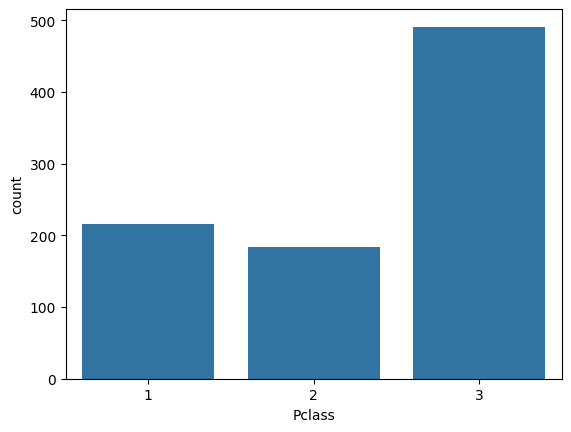

In [41]:
sns.countplot(data = df, x = "Pclass")

5. Sex

In [42]:
df["Sex"].value_counts(normalize= True) * 100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

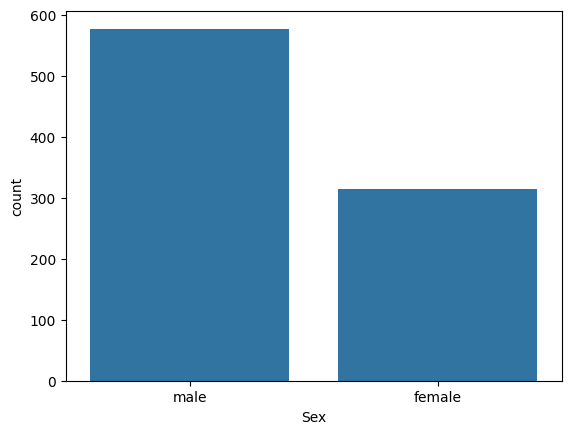

In [43]:
sns.countplot(data = df, x= "Sex")

6. SibSp

In [44]:
df["SibSp"].value_counts(normalize= True) * 100

SibSp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: proportion, dtype: float64

<Axes: xlabel='SibSp', ylabel='count'>

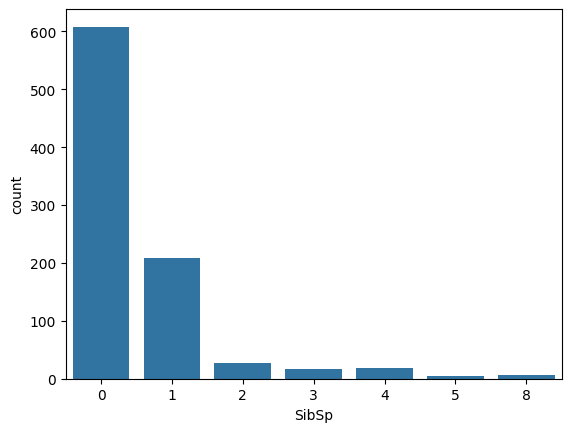

In [45]:
sns.countplot(data = df, x= "SibSp")

7. Parch

In [46]:
df["Parch"].value_counts(normalize= True) * 100

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: proportion, dtype: float64

<Axes: xlabel='Parch', ylabel='count'>

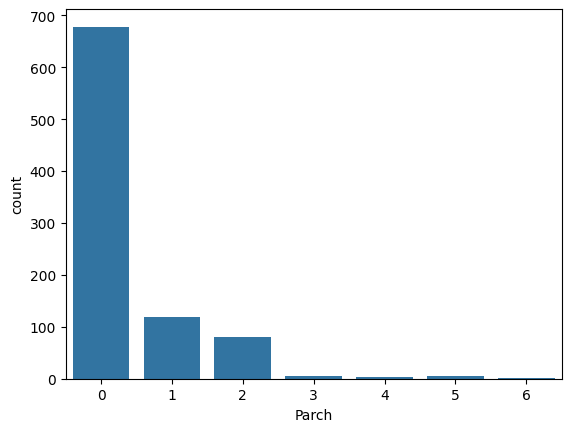

In [47]:
sns.countplot(data = df, x= "Parch")

8. Embarked

In [48]:
df["Embarked"].value_counts(normalize= True) * 100

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: proportion, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

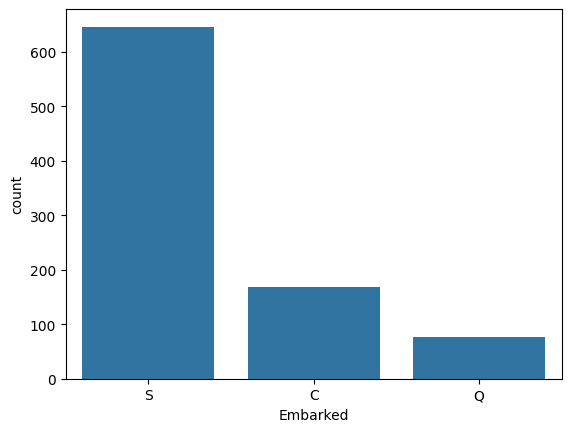

In [49]:
sns.countplot(data = df, x= "Embarked")

9. Deck

In [50]:
df["Deck"].value_counts(normalize= True) * 100

Deck
Unknown    77.104377
C           6.621773
B           5.274972
D           3.703704
E           3.591470
A           1.683502
F           1.459035
G           0.448934
T           0.112233
Name: proportion, dtype: float64

<Axes: xlabel='Deck', ylabel='count'>

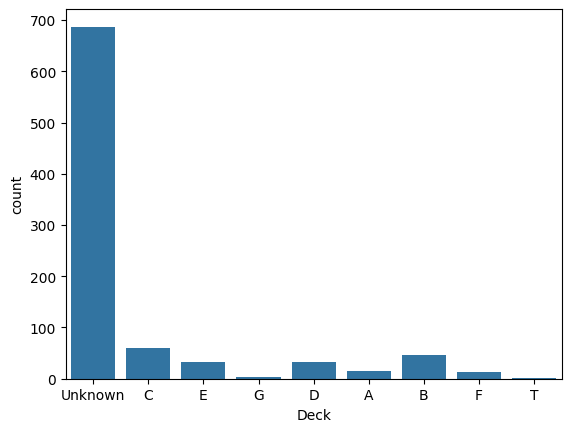

In [51]:
sns.countplot(data = df, x= "Deck")

## 2. Bivariate Analysis

1. Pclass vs Survived

In [53]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


<Axes: xlabel='Sex', ylabel='count'>

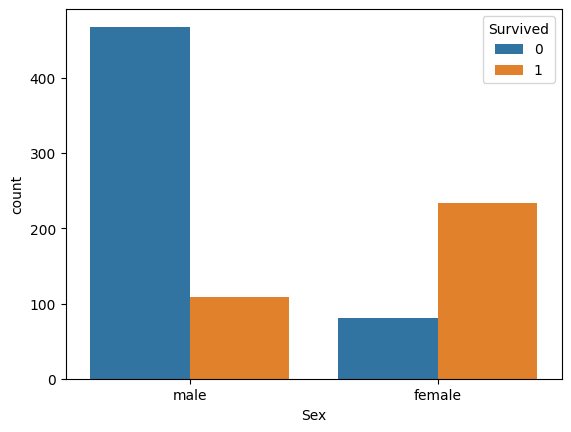

In [54]:
sns.countplot(data = df, x= "Sex", hue= "Survived")

2. SibSp vs Survived

In [55]:
pd.crosstab(df["SibSp"], df["Survived"], normalize="index") * 100

Survived,0,1
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


<Axes: xlabel='SibSp', ylabel='count'>

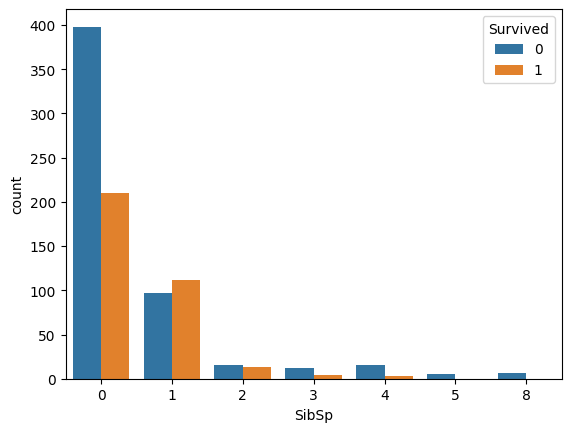

In [56]:
sns.countplot(data = df, x= "SibSp", hue= "Survived")

3. Parch vs Survived

In [57]:
pd.crosstab(df["Parch"], df["Survived"], normalize="index") * 100

Survived,0,1
Parch,,
0,65.634218,34.365782
1,44.915254,55.084746
2,50.000000,50.000000
3,40.000000,60.000000
4,100.000000,0.000000
5,80.000000,20.000000
6,100.000000,0.000000


<Axes: xlabel='Parch', ylabel='count'>

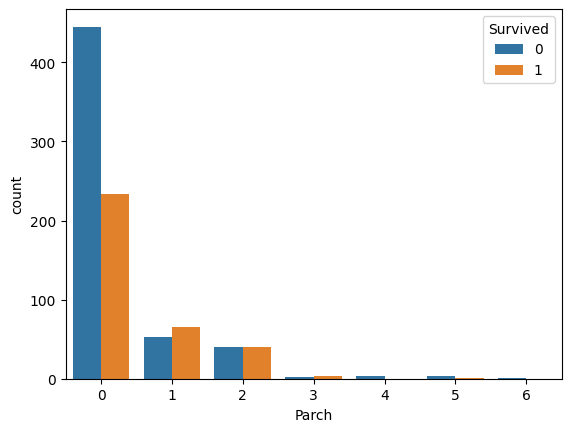

In [58]:
sns.countplot(data = df, x= "Parch", hue= "Survived")

4. Embarked vs Survived

In [59]:
pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


<Axes: xlabel='Embarked', ylabel='count'>

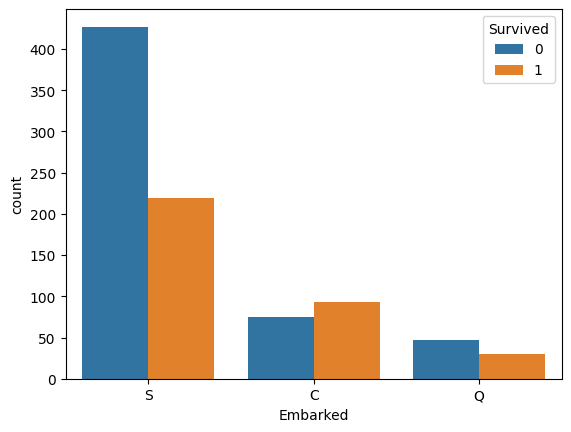

In [60]:
sns.countplot(data = df, x= "Embarked", hue= "Survived")

5. Deck vs Survived

In [61]:
pd.crosstab(df["Deck"], df["Survived"], normalize="index") * 100

Survived,0,1
Deck,,
A,53.333333,46.666667
B,25.531915,74.468085
C,40.677966,59.322034
D,24.242424,75.757576
E,25.000000,75.000000
F,38.461538,61.538462
G,50.000000,50.000000
T,100.000000,0.000000
Unknown,70.014556,29.985444


<Axes: xlabel='Deck', ylabel='count'>

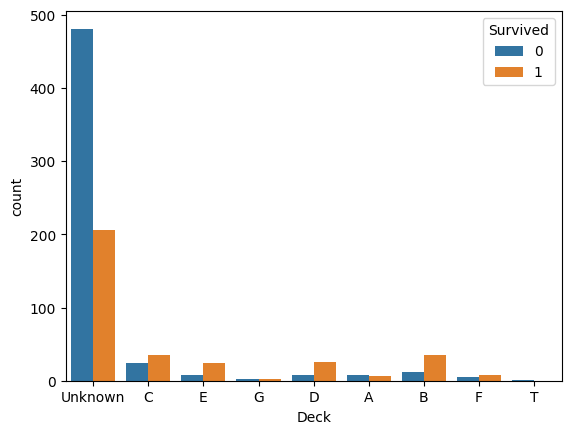

In [62]:
sns.countplot(data = df, x= "Deck", hue= "Survived")

6. Age vs Survived

In [66]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


<Axes: xlabel='Survived', ylabel='Age'>

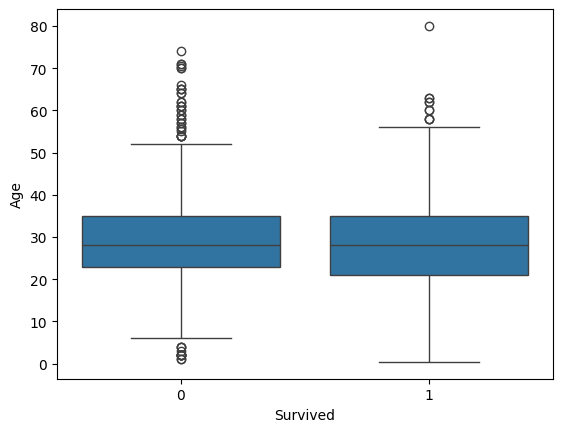

In [67]:
sns.boxplot(data= df, x= "Survived", y = "Age")

7. Fare vs Survived

In [69]:
df.groupby("Survived")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


<Axes: xlabel='Survived', ylabel='Fare'>

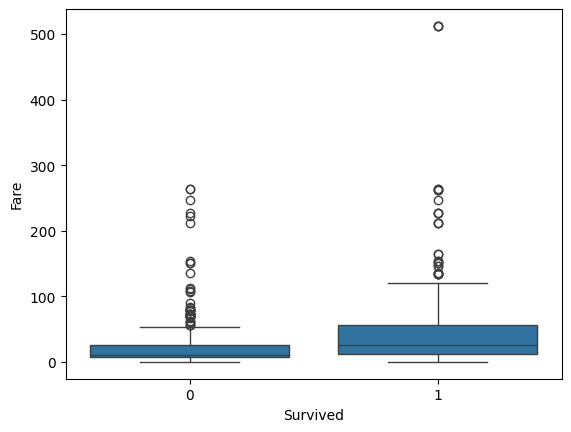

In [70]:
sns.boxplot(data= df, x= "Survived", y= "Fare")

## 3. Multivariate Analysis

## 4. Correlation

# Visualisation

# Key Findings

# Final Conclusions